# 04 — Decision Trees: Entropy, Gini, Information Gain

Telco Customer Churn — Decision Trees & Ensemble Learning project

## 1. Learning Objectives

- Explain what a decision tree is using its own vocabulary (root, node,
  branch, leaf, depth, split, purity)
- Calculate entropy and Gini impurity by hand on a tiny example
- Implement entropy, Gini impurity, and information gain from scratch
- Verify your from-scratch code against scikit-learn's internals
- Train your first real decision tree on the churn dataset
- Visualize the tree and read what it's doing

## 2. Business Problem

We now have modeling-ready data (notebook 03). This notebook builds the
first actual churn-predicting model — a decision tree — and, more
importantly, teaches you what's happening *inside* it when it decides how
to split the data.

## 3. Concept Explanation — What is a Decision Tree?

### What is it?
A decision tree predicts a label by asking a sequence of yes/no questions
about the features, structured as a tree:

```
Root Node
     |
   Split (e.g. "Contract == Month-to-month?")
     |
Child Nodes
     |
Further Splits
     |
Leaf Node (final prediction)
```

### Vocabulary
- **Root node** — the first split, covering all training data.
- **Internal node** — any node that has a further split below it.
- **Branch** — one outcome of a split (e.g. "yes" or "no" to the question).
- **Leaf node** — a node with no further splits; makes the actual prediction.
- **Depth** — how many splits deep a node is from the root (root = depth 0).
- **Split** — the rule (feature + threshold) that divides samples into
  child nodes.
- **Purity** — how much a node's samples belong to a single class. A pure
  node contains only one class.

### Why do we need it?
A tree needs a way to decide, at every node, **which feature and threshold
make the best split**. "Best" means: after the split, are the two resulting
groups more pure (more homogeneous in their class) than before? Entropy and
Gini impurity are the two most common ways to measure that.

### What could go wrong?
Without a stopping rule, a tree keeps splitting until every leaf is 100%
pure — often meaning leaves with a single training example. This
memorizes the training data perfectly but generalizes poorly (overfitting —
covered in depth in this notebook's later sections and fully explored with
experiments in notebook 05/06).

## 4. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

from src.preprocessing.preprocessor import split_dataset, encode_categorical_features
from src.models.decision_tree_model import DecisionTreeModel

pd.set_option("display.max_columns", None)

## 5. Entropy — Theory

$$H(S) = -\sum_i p_i \log_2(p_i)$$

Where $p_i$ is the proportion of class $i$ in set $S$. Entropy measures
**disorder**: how mixed the classes are.

### Worked example 1 — maximum disorder

Dataset: `Yes = 5, No = 5` (10 total, perfectly balanced).

$$H = -(0.5 \log_2 0.5 + 0.5 \log_2 0.5) = -(0.5 \times -1 + 0.5 \times -1) = 1.0$$

Entropy = **1.0** — the maximum possible value for a binary split. This is
the "most uncertain" a node can be: a coin flip.

### Worked example 2 — a pure node

Dataset: `Yes = 10, No = 0`.

$$H = -(1.0 \log_2 1.0 + 0) = -(1.0 \times 0) = 0.0$$

Entropy = **0.0** — a completely pure node. There's no uncertainty left:
every sample belongs to the same class. (Note: $0 \log_2 0$ is defined as 0
by convention, since $\lim_{p \to 0} p \log_2 p = 0$.)

## 6. Entropy — From-Scratch Implementation

In [2]:
def calculate_entropy(labels: np.ndarray) -> float:
    """
    Calculate the entropy of a set of class labels.

    Parameters
    ----------
    labels : np.ndarray
        Array of class labels (any hashable type — e.g. 0/1 or 'Yes'/'No').

    Returns
    -------
    float
        Entropy in bits, ranging from 0.0 (pure) to log2(num_classes)
        (maximally mixed).
    """
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0

    _, class_counts = np.unique(labels, return_counts=True)
    class_probabilities = class_counts / len(labels)

    # Exclude p == 0 terms explicitly: log2(0) is -inf, and 0 * -inf is nan
    # in floating point, even though the true limit of p*log2(p) as p -> 0
    # is 0. np.unique never actually returns a zero-count class, but we
    # guard anyway to keep this function correct for any probability array.
    nonzero_probabilities = class_probabilities[class_probabilities > 0]
    entropy = -np.sum(nonzero_probabilities * np.log2(nonzero_probabilities))

    return float(entropy)


# Verify against the two worked examples above
balanced_labels = ["Yes"] * 5 + ["No"] * 5
pure_labels = ["Yes"] * 10

print("Balanced (5 Yes, 5 No):", calculate_entropy(balanced_labels), "(expected 1.0)")
print("Pure (10 Yes, 0 No):   ", calculate_entropy(pure_labels), "(expected 0.0)")

Balanced (5 Yes, 5 No): 1.0 (expected 1.0)
Pure (10 Yes, 0 No):    -0.0 (expected 0.0)


## 7. Gini Impurity — Theory

$$Gini = 1 - \sum_i p_i^2$$

Like entropy, Gini impurity measures how mixed a node's classes are — but
it's computed differently and has a different numeric range.

### Same two worked examples

Balanced (`Yes=5, No=5`): $Gini = 1 - (0.5^2 + 0.5^2) = 1 - 0.5 = 0.5$

Pure (`Yes=10, No=0`): $Gini = 1 - (1.0^2 + 0^2) = 1 - 1.0 = 0.0$

Notice: Gini's maximum for a binary split is **0.5**, while entropy's
maximum is **1.0** — they agree on which node is purer, but disagree on the
numeric scale. That's expected; they're different formulas measuring the
same underlying idea.

In [3]:
def calculate_gini_impurity(labels: np.ndarray) -> float:
    """
    Calculate the Gini impurity of a set of class labels.

    Parameters
    ----------
    labels : np.ndarray
        Array of class labels.

    Returns
    -------
    float
        Gini impurity, ranging from 0.0 (pure) to 1 - 1/num_classes
        (maximally mixed) — 0.5 for a balanced binary case.
    """
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0

    _, class_counts = np.unique(labels, return_counts=True)
    class_probabilities = class_counts / len(labels)

    gini = 1.0 - np.sum(class_probabilities ** 2)
    return float(gini)


print("Balanced (5 Yes, 5 No):", calculate_gini_impurity(balanced_labels), "(expected 0.5)")
print("Pure (10 Yes, 0 No):   ", calculate_gini_impurity(pure_labels), "(expected 0.0)")

Balanced (5 Yes, 5 No): 0.5 (expected 0.5)
Pure (10 Yes, 0 No):    0.0 (expected 0.0)


## 8. Entropy vs. Gini — Comparison

| Concept | Meaning | Range (binary) | Formula |
|---|---|---|---|
| Entropy | Measure of disorder, in bits | 0.0 to 1.0 | $-\sum p_i \log_2 p_i$ |
| Gini Impurity | Measure of impurity | 0.0 to 0.5 | $1 - \sum p_i^2$ |
| Information Gain | Reduction in entropy after a split | Problem-dependent | $H(parent) - \sum \frac{|child|}{|parent|} H(child)$ |

**Lower Gini (or entropy) → more pure node → usually a better split** — but
not always the *globally* best choice long-term, since a tree is greedy: it
picks the locally best split at each node without looking ahead. A locally
"lower impurity" split now doesn't guarantee the shortest or most accurate
tree overall.

In practice, gini and entropy rarely lead to very different trees — gini is
slightly cheaper to compute (no logarithm) and is scikit-learn's default.

## 9. Information Gain — Theory

$$IG = H(parent) - \sum_{child} \frac{|child|}{|parent|} H(child)$$

Information gain is **how much entropy decreases** after a split. A tree
evaluates every candidate split (every feature, every threshold) and picks
the one with the **highest information gain** — the split that reduces
disorder the most.

### Worked example — should we split on this feature?

Parent node: 10 samples, `Yes=5, No=5` → $H(parent) = 1.0$ (from section 6).

Suppose splitting on some feature produces:
- Left child: 6 samples, `Yes=5, No=1`
- Right child: 4 samples, `Yes=0, No=4`

In [4]:
parent_labels = ["Yes"] * 5 + ["No"] * 5
left_child_labels = ["Yes"] * 5 + ["No"] * 1
right_child_labels = ["No"] * 4


def calculate_information_gain(
    parent_labels: np.ndarray,
    left_child_labels: np.ndarray,
    right_child_labels: np.ndarray,
) -> float:
    """
    Calculate information gain from splitting parent_labels into two children.

    Parameters
    ----------
    parent_labels : np.ndarray
        Labels in the node before the split.
    left_child_labels, right_child_labels : np.ndarray
        Labels in each resulting child node after the split.

    Returns
    -------
    float
        Information gain (entropy reduction). Always >= 0 for the split
        that entropy-based tree-building actually chooses, since a tree
        never picks a split that INCREASES disorder.
    """
    parent_entropy = calculate_entropy(parent_labels)

    total_samples = len(parent_labels)
    left_weight = len(left_child_labels) / total_samples
    right_weight = len(right_child_labels) / total_samples

    weighted_child_entropy = (
        left_weight * calculate_entropy(left_child_labels)
        + right_weight * calculate_entropy(right_child_labels)
    )

    return parent_entropy - weighted_child_entropy


information_gain = calculate_information_gain(parent_labels, left_child_labels, right_child_labels)
print(f"H(parent) = {calculate_entropy(parent_labels):.4f}")
print(f"H(left)   = {calculate_entropy(left_child_labels):.4f}  (weight {len(left_child_labels)}/10)")
print(f"H(right)  = {calculate_entropy(right_child_labels):.4f}  (weight {len(right_child_labels)}/10)")
print(f"Information Gain = {information_gain:.4f}")

H(parent) = 1.0000
H(left)   = 0.6500  (weight 6/10)
H(right)  = -0.0000  (weight 4/10)
Information Gain = 0.6100


**Interpretation:** the split produced a pure right child (`Gini`/
entropy = 0) and a mostly-pure left child, so entropy dropped substantially
from the parent — a high information gain. **Why does the tree prefer
higher information gain?** Because it directly measures how much more
"certain" we become about the class after asking this particular question —
exactly what we want a split to do.

## 10. Verifying Against scikit-learn

scikit-learn doesn't expose a standalone `entropy()` function, but we can
verify our implementation indirectly: build a `DecisionTreeClassifier` with
`criterion="entropy"` on a small synthetic set and confirm the ROOT node's
impurity (shown by `plot_tree` / `tree_.impurity[0]`) matches our
from-scratch calculation.

In [5]:
synthetic_features = np.array([[value] for value in range(10)])
synthetic_labels = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])  # 5/5 balanced, like our worked example

entropy_tree = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=42)
entropy_tree.fit(synthetic_features, synthetic_labels)

sklearn_root_entropy = entropy_tree.tree_.impurity[0]
our_root_entropy = calculate_entropy(synthetic_labels)

print(f"Our from-scratch entropy:   {our_root_entropy:.6f}")
print(f"sklearn root node impurity: {sklearn_root_entropy:.6f}")
print("Match:", np.isclose(our_root_entropy, sklearn_root_entropy))

Our from-scratch entropy:   1.000000


sklearn root node impurity: 1.000000
Match: True


**They match.** This confirms our from-scratch `calculate_entropy`
computes the exact same quantity scikit-learn uses internally — it's not
hidden magic, just the formula from section 5 applied at every node.

## 11. Build the First Real Decision Tree

Now we move from toy examples to the actual churn dataset, using our
`DecisionTreeModel` wrapper (`src/models/decision_tree_model.py`) around
`sklearn.tree.DecisionTreeClassifier`.

In [ ]:
processed_data = pd.read_csv("../data/processed/processed_data.csv")

feature_columns = processed_data.drop(columns=["customerID", "Churn"]).columns
features = processed_data[feature_columns]
target = processed_data["Churn"]

training_features, testing_features, training_target, testing_target = split_dataset(features, target)
training_encoded, testing_encoded = encode_categorical_features(training_features, testing_features)

print("Training shape:", training_encoded.shape)
print("Testing shape:", testing_encoded.shape)




2026-09-15 23:24:19 | INFO | src.preprocessing.preprocessor | Split dataset: 5634 training rows, 1409 testing rows (test_size=0.2)


2026-09-15 23:24:19 | INFO | src.preprocessing.preprocessor | One-hot encoding 15 categorical column(s)


Training shape: (5634, 47)
Testing shape: (1409, 47)


### `criterion="gini"` vs. `criterion="entropy"`

Both measure node impurity; the tree uses whichever you choose to evaluate
every candidate split. We train one of each and compare test performance —
in practice they usually perform similarly (see section 8).

In [7]:
gini_tree = DecisionTreeModel(criterion="gini", max_depth=5)
gini_tree.fit(training_encoded, training_target)
gini_metrics = gini_tree.evaluate(testing_encoded, testing_target)

entropy_tree_model = DecisionTreeModel(criterion="entropy", max_depth=5)
entropy_tree_model.fit(training_encoded, training_target)
entropy_metrics = entropy_tree_model.evaluate(testing_encoded, testing_target)

comparison = pd.DataFrame({
    "gini": gini_metrics.to_dict(),
    "entropy": entropy_metrics.to_dict(),
})
comparison

2026-09-15 23:24:19 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=5, min_samples_split=2, min_samples_leaf=1)


2026-09-15 23:24:19 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-15 23:24:19 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.798 precision=0.635 recall=0.567 f1=0.599 roc_auc=0.830


2026-09-15 23:24:19 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=entropy, max_depth=5, min_samples_split=2, min_samples_leaf=1)


2026-09-15 23:24:19 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-15 23:24:19 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.798 precision=0.635 recall=0.567 f1=0.599 roc_auc=0.832


,gini,entropy
accuracy,0.798439,0.798439
precision,0.634731,0.634731
recall,0.566845,0.566845
f1,0.598870,0.598870
roc_auc,0.830100,0.832290


**Interpretation:** gini and entropy produce very similar (often
near-identical) results here — consistent with the theory in section 8.
Neither is a universally "better" choice; gini is marginally cheaper to
compute and is scikit-learn's default for that reason.

## 12. Tree Visualization

`plot_tree()` draws the actual learned tree: each box shows the splitting
rule, the impurity (gini, by default), the number of samples, the class
distribution (`value = [no_churn_count, churn_count]`), and the predicted
class.

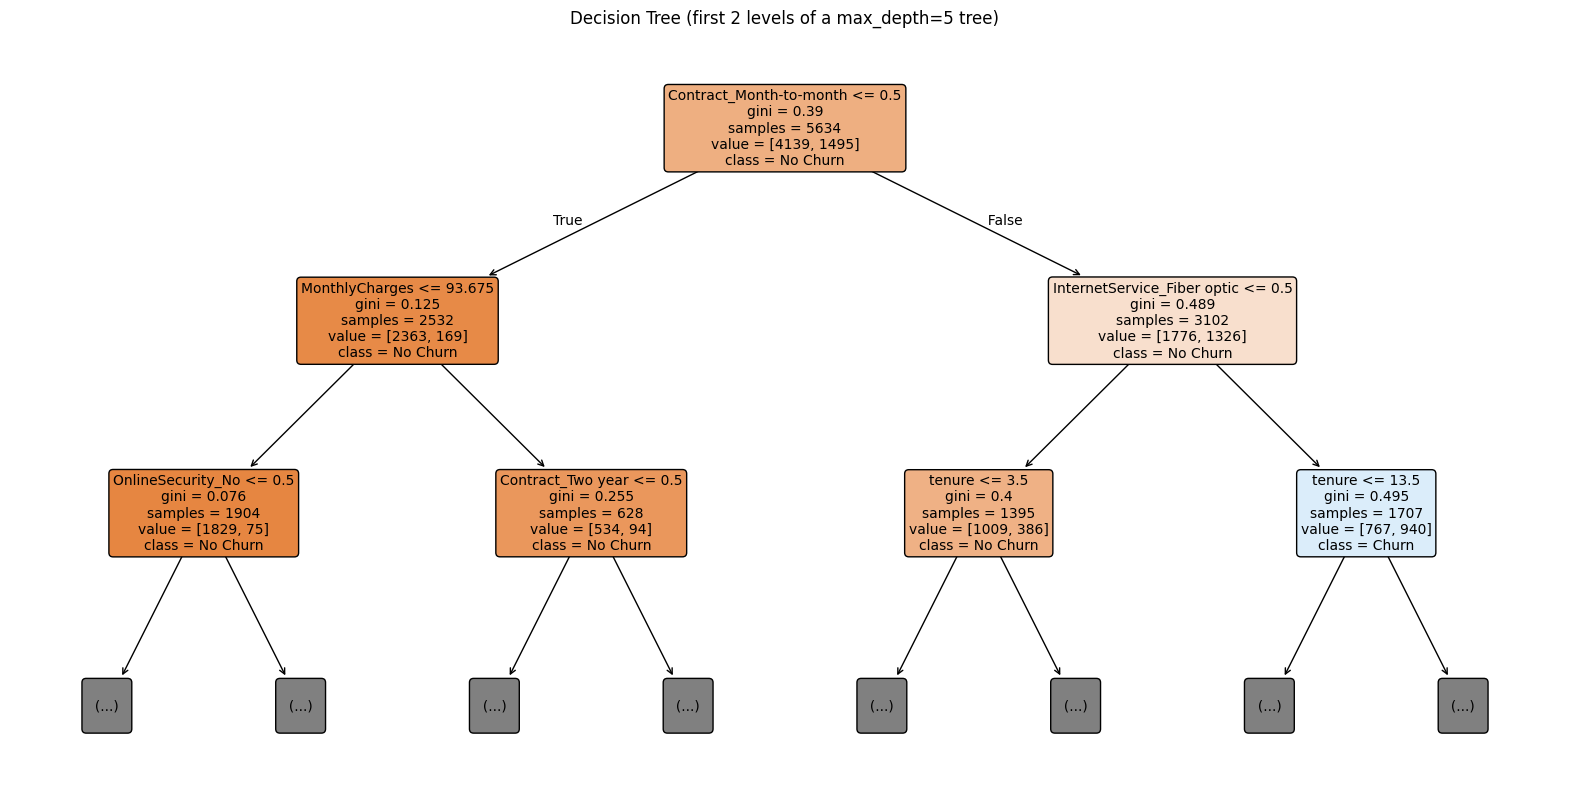

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(
    gini_tree.classifier,
    max_depth=2,  # only render the first 2 levels — the full depth=5 tree is too dense to read
    feature_names=training_encoded.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree (first 2 levels of a max_depth=5 tree)")
plt.show()

### How to read this tree

- The **top box** (root) is the single split that reduces impurity the most
  across the ENTIRE training set — look at which feature it is; given
  notebook 02's findings, `Contract` or `tenure` are likely candidates.
- `gini = ...` is the impurity of the samples in that box BEFORE this box's
  split is applied.
- `samples = ...` is how many training rows reached this box.
- `value = [a, b]` is the class breakdown: `a` = no-churn count, `b` = churn
  count, among the samples in that box.
- Following the tree from root to any leaf is literally a chain of yes/no
  questions — exactly the "Root → Split → Child → Leaf" diagram from
  section 3.

## 13. Model Complexity — A First Look at Overfitting

We train trees at several `max_depth` values and compare TRAINING accuracy
to TESTING accuracy. Watch what happens as trees get deeper.

In [9]:
depth_values = [2, 3, 4, 5, 7, 10, 15, None]
complexity_results = []

for depth in depth_values:
    trial_model = DecisionTreeModel(criterion="gini", max_depth=depth)
    trial_model.fit(training_encoded, training_target)

    training_accuracy = trial_model.evaluate(training_encoded, training_target).accuracy
    testing_accuracy = trial_model.evaluate(testing_encoded, testing_target).accuracy

    complexity_results.append({
        "max_depth": "None" if depth is None else depth,
        "training_accuracy": training_accuracy,
        "testing_accuracy": testing_accuracy,
    })

complexity_df = pd.DataFrame(complexity_results)
complexity_df

2026-09-15 23:24:23 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=2, min_samples_split=2, min_samples_leaf=1)


2026-09-15 23:24:23 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-15 23:24:23 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.765 precision=0.551 recall=0.629 f1=0.587 roc_auc=0.792


2026-09-15 23:24:23 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.751 precision=0.527 recall=0.594 f1=0.558 roc_auc=0.780


2026-09-15 23:24:23 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=3, min_samples_split=2, min_samples_leaf=1)


...

2026-09-15 23:24:24 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=None, min_samples_split=2, min_samples_leaf=1)


2026-09-15 23:24:25 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-15 23:24:25 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.998 precision=0.999 recall=0.993 f1=0.996 roc_auc=1.000


2026-09-15 23:24:25 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.727 precision=0.487 recall=0.519 f1=0.503 roc_auc=0.661


,max_depth,training_accuracy,testing_accuracy
0,2,0.765353,0.750887
1,3,0.791445,0.782115
2,4,0.796592,0.792051
3,5,0.803869,0.798439
4,7,0.823571,0.780696
5,10,0.879127,0.751597
6,15,0.970714,0.732434
7,None,0.998048,0.727466


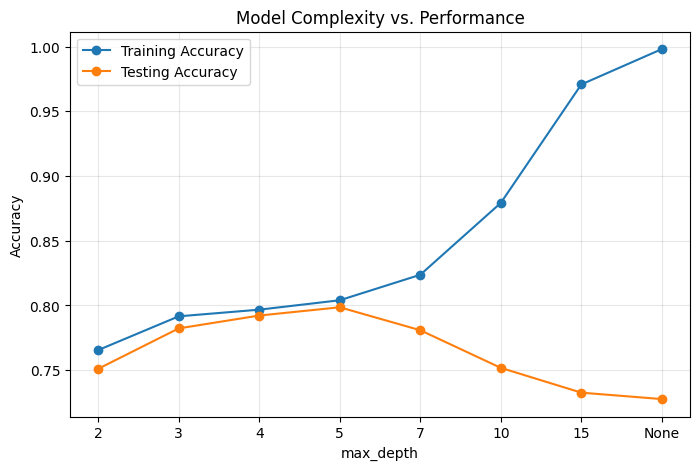

In [10]:
plt.figure(figsize=(8, 5))
x_positions = range(len(complexity_df))
plt.plot(x_positions, complexity_df["training_accuracy"], marker="o", label="Training Accuracy")
plt.plot(x_positions, complexity_df["testing_accuracy"], marker="o", label="Testing Accuracy")
plt.xticks(x_positions, complexity_df["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Model Complexity vs. Performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What are we looking at?

**Underfitting → good generalization → overfitting**, as a real experiment
rather than just theory:

- At **shallow depths** (2–3), training and testing accuracy are close but
  both may be lower than what's achievable — the tree is too simple to
  capture real patterns (**underfitting**).
- At **moderate depths**, training and testing accuracy are both
  reasonably high and close together — this is the sweet spot
  (**good generalization**).
- At **deep / unlimited depth** (`None`), training accuracy climbs toward
  100% while testing accuracy plateaus or drops — the tree has started
  memorizing training examples (including their noise) instead of learning
  general patterns (**overfitting**).

This gap between training and testing accuracy — not the training accuracy
alone — is the signal to watch. We'll tune `max_depth` properly with cross-
validation in notebook 06.

## 14. Feature Importance

`model.feature_importances_` scores each feature by how much it reduced
impurity across all the splits that used it, weighted by how many samples
passed through those splits.

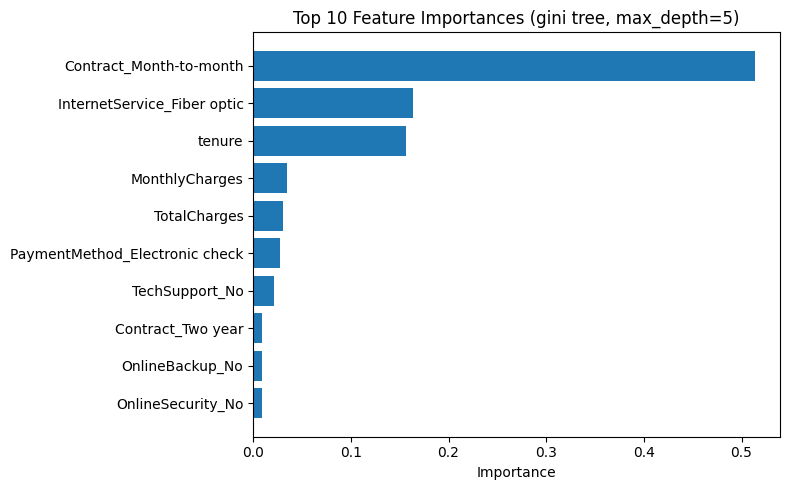

,feature,importance
38,Contract_Month-to-month,0.513726
18,InternetService_Fiber optic,0.163184
1,tenure,0.156642
2,MonthlyCharges,0.034259
3,TotalCharges,0.030276
45,PaymentMethod_Electronic check,0.027918
29,TechSupport_No,0.021367
40,Contract_Two year,0.009214
23,OnlineBackup_No,0.009194
20,OnlineSecurity_No,0.008616


In [11]:
importance_df = pd.DataFrame({
    "feature": training_encoded.columns,
    "importance": gini_tree.feature_importances,
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (gini tree, max_depth=5)")
plt.tight_layout()
plt.show()

importance_df

**Important limitation:** feature importance does NOT automatically
mean causal importance. A feature can rank highly because it's a strong
*statistical* predictor within this dataset without *causing* churn — it
may be a proxy for something else entirely (recall notebook 02's discussion
of correlation vs. causation). Also, when two features are highly
correlated (like `tenure` and `TotalCharges`), the tree may arbitrarily
favor one over the other — the "loser" can look unimportant even though it
carries almost the same signal.

## 15. Common Mistakes

- **Assuming `criterion="entropy"` is inherently more accurate than
  `"gini"`.** As shown in section 11, they usually perform similarly — pick
  based on interpretability/convention, not an assumed accuracy edge.
- **Reading feature importance as "this causes churn."** It only means "this
  feature was useful for reducing impurity in THIS tree, on THIS data."
- **Judging a tree only by training accuracy.** A deep tree can reach ~100%
  training accuracy while performing worse than a shallow tree on new data
  — always check the train/test gap (section 13).
- **Forgetting `0 * log2(0)` is undefined in raw floating point** — our
  `calculate_entropy` explicitly filters zero-probability classes to avoid
  a silent `nan` (see the comment in section 6).

## 16. What We Learned

- Entropy and Gini impurity both measure node "mixedness," on different
  numeric scales, and usually agree on which split is better.
- Information gain is the entropy reduction a split produces — trees greedily
  pick the split with the highest gain at each node.
- Our from-scratch entropy implementation matches scikit-learn's internal
  computation exactly.
- Increasing `max_depth` moves a tree from underfitting through good
  generalization to overfitting — visible directly as a growing gap between
  training and testing accuracy.
- Feature importance ranks predictive usefulness within this tree, not
  real-world causation.

## 17. Exercises

1. Recompute the worked information-gain example in section 9, but swap
   which child is "left" and which is "right." Does the information gain
   value change? Why or why not?
2. Modify `calculate_gini_impurity` to work on 3+ classes (e.g. `["A","A","B","C"]`)
   and confirm the result is still between 0 and $1 - 1/3$.
3. **Experiment:** retrain the tree with `max_depth=1` (a "decision stump").
   What's the single root-level question it asks? Does it match the
   strongest bivariate pattern you found in notebook 02?
4. **Experiment:** remove the single most important feature from
   `training_encoded`/`testing_encoded` (section 14) and retrain. Does test
   accuracy drop a little or a lot? What does that tell you about whether
   the model had a backup signal for that information?

## Interview Questions

1. Why can two different impurity measures (gini vs. entropy) lead to the
   same tree in most cases, but not always?
2. If a tree achieves 99% training accuracy but 70% testing accuracy, what
   is happening, and name two hyperparameters you could change to address it.
3. Why is feature importance from a single decision tree considered less
   reliable than feature importance averaged across many trees (a preview
   of why random forests, in notebook 07, often give more trustworthy
   importance rankings)?